<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Project 2: Ames Housing sale price

## Problem Statement:

Create a regression model based on the _**Ames Housing Dataset**_. This model will predict the price of a house at sale. 

## Background
---

Project 2 involves using a well-known _**Ames housing data**_ to create a regression model that predicts the price of houses in Ames, IA. The Ames Housing Dataset is an exceptionally detailed and robust dataset with over 80 columns of different features relating to houses. I am allowed to use any and all features that are present in this dataset. <br><br> This is also a [Kaggle challenge](https://www.kaggle.com/competitions/dsi-us-11-project-2-regression-challenge/overview), so I would need to make at least one (and hopefully, multiple) submissions towards this regression challenge. Kaggle leaderboard standings will be determined by root mean squared error (`RMSE`).

### Data provided
There are 3 datasets included in the [`datasets`](datasets/) folder for this project.
* [`sample_sub_reg.csv`](datasets/sample_sub_reg.csv): An example of a correctly formatted submission for this challenge (with a random number provided as predictions for `SalePrice`). My submission to Kaggle must match this format
* [`test.csv`](datasets/test.csv): Contains the test data for my model. This data is fed into my regression model to make predictions. Target variable (`SalePrice`) is excluded from this data.
* [`train.csv`](datasets/train.csv): Contains all of the training data for my model. 

### Goal
To predict the sales price for each house. For each Id in the test set, I must predict the value of the SalePrice variable.

## Data Dictionary
---
[Link](http://jse.amstat.org/v19n3/decock/DataDocumentation.txt)

### Contents:
* [Background](#Background)
* [Data Dictionary](#Data-Dictionary)
* [Data Import, Validation & Cleaning](#Data-Import,-Validation-and-Cleaning)
* [Exploratory Data Analysis](#Exploratory-Data-Analysis)
* [Processed Data](#Processed-Dataframes:)
* [Train-Test-Split](#Train-test-split:)
* [Imputation of `Lot Frontage`](#Imputation-of-train-set:)
* [Algorithm](#LassoCV)
* [Multicollinearity](#Checking-for-multicollinearity:)
* [Rerun Algorithm](#Rerun-Lasso-Model)
* [Repeat Multicollinearity check](#Repeat-multicollinearity-check)
* [GridSearchCV](#GridSearch-CV)
* [Kaggle Submission](#Kaggle-Submission-preparation)
* [Evaluation of Model features](#Evaluation-of-model-features-effect-on-SalePrice)

## Data Import, Validation and Cleaning
---

In [1]:
# import modules for data import and cleaning
import numpy as np
import pandas as pd

In [2]:
# load data
train_df = pd.read_csv('datasets/train.csv')

### train_df

In [ ]:
# check import successful
train_df.head(3)

In [ ]:
# to get an idea of how much data I am dealing with
print(f'train_df shape: {train_df.shape}')

In [ ]:
train_df.describe().T

_Min and max values of numerical columns look reasonable_

In [ ]:
# checking dtypes and null values
train_df.info()

In [ ]:
# limit rows to view for easier viewing
train_df.isnull().sum().sort_values(ascending=False)[:27]

In [ ]:
# check for percentage of null values in columns
(train_df.isnull().sum().sort_values(ascending=False) * 100 / len(train_df))[:27]

_Linear regression models cannot accept any missing values, so all missing values must be dealt with before model fitting._<br><br>
_There are 6 features that have a significant percentage of null values (`> 10%`), 5 of them are categorical, and the null values have meaning. Using `pd.get_dummies` resulted in about 230 addiional features. So I will use ordinal encoding for features that seemed to have ordinal values. E.g. `Pool QC`, `Bsmt Cond`._<br><br>
_The features with small percentages of null values seem to be related to each other. E.g. `Garage`-related, `Bsmt`-related, or `Mas Vnr`-related. I suspect that some of these may be MAR(Missing At Random) values, meaning they are dependent on the values of other features. Later I will explore if these features are truly MAR or MCAR(Completely Missing At Random). If so,  dropping the rows may be a reasonable thing to do._<br><br>

_**Functions for label encoding presence/absence of attribute:**_

In [3]:
def yes_no_col(df,root,new):
    conditions = [
        (df[root]=='Ex') | (df[root]=='Gd')|
        (df[root]=='TA') | (df[root]=='Fa')|
        (df[root]=='Po'), 
        (df[root]=='NA')
    ]
    values = [1, 0]
    df[new] = np.select(conditions, values)

In [4]:
def yes_no_pool(df,root,new):
    conditions = [
        (df[root]=='Ex') | (df[root]=='Gd')|
        (df[root]=='TA') | (df[root]=='Fa'), 
        (df[root]=='NA')
    ]
    values = [1, 0]
    df[new] = np.select(conditions, values)

_**Calling functions to feature engineer:**_

In [5]:
yes_no_col(train_df,root='Bsmt Cond',new='have_bsmt')
yes_no_col(train_df,root='Fireplace Qu',new='have_fireplace')
yes_no_col(train_df,root='Garage Cond',new='have_garage')
yes_no_pool(train_df,root='Pool QC',new='have_pool')

_**Checking that function performed as desired:**_

In [ ]:
train_df.groupby('have_bsmt')['Bsmt Cond'].value_counts(dropna=False)

In [ ]:
train_df.groupby('have_fireplace')['Fireplace Qu'].value_counts(dropna=False)

In [ ]:
train_df.groupby('have_garage')['Garage Cond'].value_counts(dropna=False)

In [ ]:
train_df.groupby('have_pool')['Pool QC'].value_counts(dropna=False)

_**Functions for ordinal label encoding of attributes:**_

In [6]:
def int_rank1(df,col):
    return df[col].replace({'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1}, inplace=True)

In [ ]:
# check original count
train_df['Exter Qual'].value_counts(dropna=False) 

In [7]:
# call function
int_rank1(train_df, col='Exter Qual')
int_rank1(train_df, col='Exter Cond')
int_rank1(train_df, col='Heating QC')
int_rank1(train_df, col='Kitchen Qual')

In [ ]:
# check function return
train_df['Exter Qual'].value_counts(dropna=False)

In [8]:
def int_rank2(df,col):
    return df[col].replace({'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, np.nan:0}, inplace=True)

In [ ]:
# check original count
train_df['Bsmt Qual'].value_counts(dropna=False)

_**Call function:**_

In [9]:
int_rank2(train_df,col='Bsmt Qual')
int_rank2(train_df,col='Bsmt Cond')
int_rank2(train_df,col='Fireplace Qu')
int_rank2(train_df,col='Garage Qual')
int_rank2(train_df,col='Garage Cond')

In [ ]:
# check function return
train_df['Bsmt Qual'].value_counts(dropna=False)

In [ ]:
# original count
train_df['Bsmt Exposure'].value_counts(dropna=False)

In [10]:
# more replacement of ordinal categorical values with numerical values
train_df['Utilities'].replace({'AllPub':4, 'NoSewr':3, 'NoSeWa':2, 'ELO':1}, inplace=True)
train_df['Land Slope'].replace({'Gtl':3, 'Mod':2, 'Sev':1}, inplace=True)
train_df['Bsmt Exposure'].replace({'Gd':4, 'Av':3, 'Mn':2, 'No':1, np.nan:0}, inplace=True)
train_df['Heating QC'].replace({'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1}, inplace=True)
train_df['Central Air'].replace({'Y':1, 'N':0}, inplace=True)
train_df['Functional'].replace({'Typ':8, 'Min1':7, 'Min2':6, 'Mod':5, 'Maj1':4, 'Maj2':3, 'Sev':2, 'Sal':1}, inplace=True)  
train_df['Garage Finish'].replace({'Fin':3, 'RFn':2, 'Unf':1, np.nan:0}, inplace=True)
train_df['Pool QC'].replace({'Ex':4, 'Gd':3, 'TA':2, 'Fa':1, np.nan:0}, inplace=True)

In [ ]:
# check change
train_df['Bsmt Exposure'].value_counts(dropna=False)

In [102]:
# check what features left that have values still in string form
train_df.dtypes[train_df.dtypes=='object']

MS Zoning         object
Street            object
Alley             object
Lot Shape         object
Land Contour      object
Lot Config        object
Neighborhood      object
Condition 1       object
Condition 2       object
Bldg Type         object
House Style       object
Roof Style        object
Roof Matl         object
Exterior 1st      object
Exterior 2nd      object
Mas Vnr Type      object
Foundation        object
BsmtFin Type 1    object
BsmtFin Type 2    object
Heating           object
Electrical        object
Garage Type       object
Paved Drive       object
Fence             object
Misc Feature      object
Sale Type         object
dtype: object

_**Explore counts within categorical features that have no ordinal values:**_

In [133]:
def val_cnt(feature):
    return train_df[[feature]].value_counts(dropna=False)

In [134]:
val_cnt(feature='MS Zoning')

MS Zoning
RL           1598
RM            316
FV            101
C (all)        19
RH             14
A (agr)         2
I (all)         1
dtype: int64

In [123]:
val_cnt(feature='Street')

Street
Pave      2044
Grvl         7
dtype: int64

In [124]:
val_cnt(feature='Alley')

Alley
NaN      1911
Grvl       85
Pave       55
dtype: int64

In [125]:
val_cnt(feature='Lot Shape')

Lot Shape
Reg          1295
IR1           692
IR2            55
IR3             9
dtype: int64

In [126]:
val_cnt(feature='Land Contour')

Land Contour
Lvl             1843
HLS               85
Bnk               80
Low               43
dtype: int64

In [127]:
val_cnt(feature='Lot Config')

Lot Config
Inside        1503
Corner         348
CulDSac        131
FR2             60
FR3              9
dtype: int64

In [135]:
val_cnt(feature='Neighborhood')

Neighborhood
NAmes           310
CollgCr         180
OldTown         163
Edwards         143
Somerst         130
NridgHt         122
Gilbert         116
Sawyer          111
SawyerW          87
NWAmes           87
Mitchel          82
BrkSide          76
Crawfor          71
IDOTRR           69
Timber           48
NoRidge          48
StoneBr          38
SWISU            32
ClearCr          27
MeadowV          24
Blmngtn          22
BrDale           19
NPkVill          17
Veenker          17
Blueste           6
Greens            3
GrnHill           2
Landmrk           1
dtype: int64

In [136]:
val_cnt(feature='Condition 1')

Condition 1
Norm           1767
Feedr           109
Artery           70
RRAn             36
PosN             27
RRAe             21
PosA             12
RRNn              6
RRNe              3
dtype: int64

In [137]:
val_cnt(feature='Condition 2')

Condition 2
Norm           2025
Feedr            11
Artery            5
PosA              3
PosN              3
RRNn              2
RRAe              1
RRAn              1
dtype: int64

In [138]:
val_cnt(feature='Bldg Type')

Bldg Type
1Fam         1700
TwnhsE        161
Duplex         75
Twnhs          69
2fmCon         46
dtype: int64

In [139]:
val_cnt(feature='House Style')

House Style
1Story         1059
2Story          598
1.5Fin          218
SLvl             94
SFoyer           50
2.5Unf           14
1.5Unf           12
2.5Fin            6
dtype: int64

In [140]:
val_cnt(feature='Roof Style')

Roof Style
Gable         1619
Hip            397
Flat            13
Gambrel         12
Mansard          7
Shed             3
dtype: int64

In [141]:
val_cnt(feature='Roof Matl')

Roof Matl
CompShg      2025
Tar&Grv        15
WdShngl         5
WdShake         4
ClyTile         1
Membran         1
dtype: int64

In [142]:
val_cnt(feature='Exterior 1st')

Exterior 1st
VinylSd         724
MetalSd         331
HdBoard         300
Wd Sdng         276
Plywood         152
CemntBd          90
BrkFace          64
WdShing          45
AsbShng          33
Stucco           27
BrkComm           3
CBlock            2
Stone             2
AsphShn           1
ImStucc           1
dtype: int64

In [143]:
val_cnt(feature='Exterior 2nd')

Exterior 2nd
VinylSd         721
MetalSd         324
HdBoard         275
Wd Sdng         262
Plywood         185
CmentBd          90
Wd Shng          63
BrkFace          34
Stucco           30
AsbShng          28
Brk Cmn          17
ImStucc          11
Stone             6
AsphShn           3
CBlock            2
dtype: int64

In [144]:
val_cnt(feature='Mas Vnr Type')

Mas Vnr Type
None            1218
BrkFace          630
Stone            168
NaN               22
BrkCmn            13
dtype: int64

In [145]:
val_cnt(feature='Foundation')

Foundation
PConc         926
CBlock        863
BrkTil        221
Slab           34
Stone           5
Wood            2
dtype: int64

In [146]:
val_cnt(feature='BsmtFin Type 1')

BsmtFin Type 1
GLQ               615
Unf               603
ALQ               293
BLQ               200
Rec               183
LwQ               102
NaN                55
dtype: int64

In [147]:
val_cnt(feature='BsmtFin Type 2')

BsmtFin Type 2
Unf               1749
Rec                 80
LwQ                 60
NaN                 56
BLQ                 48
ALQ                 35
GLQ                 23
dtype: int64

In [148]:
val_cnt(feature='Heating')

Heating
GasA       2018
GasW         20
Wall          6
Grav          5
OthW          2
dtype: int64

In [149]:
val_cnt(feature='Electrical')

Electrical
SBrkr         1868
FuseA          140
FuseF           35
FuseP            7
Mix              1
dtype: int64

In [150]:
val_cnt(feature='Garage Type')

Garage Type
Attchd         1213
Detchd          536
BuiltIn         132
NaN             113
Basment          27
2Types           19
CarPort          11
dtype: int64

In [151]:
val_cnt(feature='Paved Drive')

Paved Drive
Y              1861
N               151
P                39
dtype: int64

In [152]:
val_cnt(feature='Fence')

Fence
NaN      1651
MnPrv     227
GdPrv      83
GdWo       80
MnWw       10
dtype: int64

In [153]:
val_cnt(feature='Misc Feature')

Misc Feature
NaN             1986
Shed              56
Gar2               4
Othr               3
Elev               1
TenC               1
dtype: int64

In [154]:
val_cnt(feature='Sale Type')

Sale Type
WD           1781
New           160
COD            63
ConLD          17
CWD            10
ConLI           7
ConLw           5
Con             4
Oth             4
dtype: int64

### train_dum

In [11]:
prefix_dict = {'Misc Feature': 'misc_f', 'Alley': 'alley', 'Fence': 'fence',
               'Garage Type': 'grge_t','BsmtFin Type 2': 'bsmtf_t2', 'BsmtFin Type 1': 'bsmtf_t1', 
               'Mas Vnr Type': 'mvt','MS Zoning': 'msz', 'Street': 'st', 'Lot Shape':'lt_s', 
               'Land Contour': 'ld_c', 'Lot Config': 'lt_c', 'Neighborhood': 'nbrhd', 
               'Condition 1': 'cdn_1', 'Condition 2': 'cdn_2', 'Bldg Type': 'bdg_t', 
               'House Style': 'hse_s', 'Roof Style': 'rf_s', 'Roof Matl': 'rf_m', 
               'Exterior 1st': 'ex_1', 'Exterior 2nd': 'ex_2', 'Foundation': 'fdn', 
               'Heating': 'htg', 'Electrical': 'elec', 'Paved Drive': 'pvdr','Sale Type': 'sle_t'
              }

columns_list = ['Misc Feature','Alley','Fence','Garage Type','BsmtFin Type 2','BsmtFin Type 1',
                'Mas Vnr Type','MS Zoning','Street','Lot Shape','Land Contour','Lot Config',
               'Neighborhood','Condition 1','Condition 2','Bldg Type', 'House Style',
               'Roof Style','Roof Matl','Exterior 1st','Exterior 2nd','Foundation','Heating',
                'Electrical','Paved Drive','Sale Type'
               ]

train_dum = pd.get_dummies(data=train_df, prefix=prefix_dict, dummy_na=True, columns=columns_list)
train_dum.head(3)

,Id,PID,MS SubClass,Lot Frontage,Lot Area,Utilities,Land Slope,Overall Qual,Overall Cond,Year Built,...,sle_t_COD,sle_t_CWD,sle_t_Con,sle_t_ConLD,sle_t_ConLI,sle_t_ConLw,sle_t_New,sle_t_Oth,sle_t_WD,sle_t_nan
0,109,533352170,60,NaN,13517,4,3,6,8,1976,...,0,0,0,0,0,0,0,0,1,0
1,544,531379050,60,43.0,11492,4,3,7,5,1996,...,0,0,0,0,0,0,0,0,1,0
2,153,535304180,20,68.0,7922,4,3,5,7,1953,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
# relook at what null values that are left undummified
train_dum.isnull().sum().sort_values(ascending=False)[:12]

In [ ]:
# percentage of null values in each column of dummified train data
(train_dum.isnull().sum().sort_values(ascending=False) * 100 / len(train_dum))[:12]

_Now there are 2 features left with high percentage of null values (>5%)._<br><br> 
_For `Lot Frontage` feature, with percentage of null values at 16%, either I would remove the feature, or replace missing values by imputation using `KNN imputation`, depending on the type of missing values. However the imputation would only be done after train-test-split on the training set._<br><br>
_For `Garage Yr Blt`, the missing values are Missing At Random values, since they seem to be dependent on the values of other `Garage`-related features. Specifically, they correspond with properties that have **no garage**. Imputation will likely contribute false information, where the missing values have a reason to be missing. If I drop the rows with missing values in `Garage Yr Blt` feature, I would also lose the data of **no garage** from categorical features `Garage Finish`, `Garage Qual` and `Garage Cond`. So I decided the best course of action is to drop the `Garage Yr Blt` feature._<br><br>
_As for the other features with percentage of null values at `<5%`, I would keep the feature but drop the rows with the missing values._

In [ ]:
'''
Displaying that there is no clear relationship between
`Lot Frontage` feature and other `Lot`-related features
'''
train_df.loc[train_df['Lot Frontage'].isnull(), ['Lot Frontage','Lot Area','Lot Shape','Lot Config']].head(3)

_There is no discernable pattern or explanation as to why the values are missing for `Lot Frontage` feature. I also wish to preserve this feature since meaning from this feature does not seemed to be represented in other features. I would impute the missing values using `KNN imputation`after train-test-split._ 

In [ ]:
'''
Displaying `Garage Yr Blt` missing value relationship 
with other categorical `Garage`-related features
'''
train_df.loc[train_df['Garage Yr Blt'].isnull(), ['Garage Yr Blt','Garage Finish','Garage Cars','Garage Area','Garage Qual','Garage Cond']].head(3)

_Rows with missing values in the features with **<5%** null values_

In [ ]:
train_df.loc[train_df['Garage Cars'].isnull(), ['Garage Yr Blt','Garage Finish','Garage Cars','Garage Area','Garage Qual','Garage Cond']]

In [ ]:
train_df.loc[train_df['BsmtFin SF 2'].isnull(), ['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin SF 1','BsmtFin Type 2','BsmtFin SF 2','Bsmt Unf SF','Total Bsmt SF']]

In [ ]:
train_df.loc[train_df['Bsmt Full Bath'].isnull(), ['Bsmt Full Bath','Bsmt Half Bath']]

In [ ]:
'''
Instead of None and '0' values, these have blank spaces in the source data. 
So likely these are MCAR values. 
'''
train_df.loc[train_df['Mas Vnr Area'].isnull(), ['Mas Vnr Area','Mas Vnr Type']].head(3)

_To get the list of row indices to drop, I get the list of row indices with null values in the `Garage Cars`, `Bsmt Full Bath` and `Mas Vnr Area` features._

In [12]:
list1 = train_df.index[train_df['Garage Cars'].isnull()].tolist()
list1

[1712]

_Since the row with `BsmtFin SF 2` null value is also has null value in `Bsmt Full Bath`, I will just get the row indices from `Bsmt Full Bath` null list_ 

In [13]:
list2 = train_df.index[train_df['Bsmt Full Bath'].isnull()].tolist()
list2

[616, 1327]

In [14]:
list3 = train_df.index[train_df['Mas Vnr Area'].isnull()].tolist()
list3[:5]

[22, 41, 86, 212, 276]

_Join the 3 lists together, may contain duplicate indices, so will convert to set, which only keep unique values_

In [15]:
drop_list = list1 + list2 + list3
len(drop_list)

25

In [16]:
drop_set = set(drop_list)
len(drop_set) # no duplicate indices

25

### train_drop

In [17]:
'''
created new dataframe variable just in case I needed 
the dataframe without any dropped rows and/or feature(s) to go back to
'''
train_drop = train_dum.drop(index=drop_set, columns=['Garage Yr Blt'])

In [ ]:
# checking what null values that are left
train_drop.isnull().sum().sort_values(ascending=False)[:3]

In [ ]:
# percentage of null values that are left
(train_drop.isnull().sum().sort_values(ascending=False) * 100 / len(train_drop))[:3]

## Exploratory Data Analysis
---

_Before train-test-split, outliers need to be dealt with, especially for linear regression models. Linear regression models are easily influenced by outliers._

__Contents:__
1. [Distribution exploration](#Exploring-distributions-using-histograms-and-scatterplots:)
1. [Dealing with outliers](#Dealing-with-outliers:)

_For exploration of trends within the train data vs. `SalePrice` feature, I would use `train_df` (no rows and columns dropped, and no dummification), for easier comparison of the features._

## Exploring distributions using histograms and scatterplots:
---

In [18]:
# import modules for data exploration
from scipy import stats
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

>_Scatterplot is useful to reveal outliers. Histogram is useful to show distribution of values, but not outliers, as outliers usually appear in low frequency, so the x-axis would be unusually long with no peak. And it would be difficult to define what is the threshold for outliers from a histogram._<br><br>
_Since I am ultimately trying to predict `SalePrice`, I will be comparing features with `SalePrice` to determine outliers._

**Numerical features are:** <br>
[`Lot Frontage`](#Lot-Frontage-distribution:); [`Lot Area`](#Lot-Area-distribution:); [`Year Built`](#Year-Built-distribution:); [`Year Remod/Add`](#Year-Remod/Add-distribution:); [`Mas Vnr Area`](#Mas-Vnr-Area-distribution:); [`BsmtFin SF 1`](#BsmtFin-SF-1-distribution:); [`BsmtFin SF 2`](#BsmtFin-SF-2-distribution:); [`Bsmt Unf SF`](#Bsmt-Unf-SF-distribution:); [`Total Bsmt SF`](#Total-Bsmt-SF-distribution:); [`1st Flr SF`](#1st-Flr-SF-distribution:); [`2nd Flr SF`](#2nd-Flr-SF-distribution:); [`Low Qual Fin SF`](#Low-Qual-Fin-SF-distribution:); [`Gr Liv Area`](#Gr-Liv-Area-distribution:); [`Bsmt Full Bath`](#Bsmt-Full-Bath-distribution:); [`Bsmt Half Bath`](#Bsmt-Half-Bath-distribution:); [`Full Bath`](#Full-Bath-distribution:); [`Half Bath`](#Half-Bath-distribution:); [`Bedroom AbvGr`](#Bedroom-AbvGr-distribution:); [`Kitchen AbvGr`](#Kitchen-AbvGr-distribution:); [`TotRms AbvGrd`](#TotRms-AbvGrd-distribution:); [`Fireplaces`](#Fireplaces-distribution:); [`Garage Cars`](#Garage-Cars-distribution:); [`Garage Area`](#Garage-Area-distribution:); [`Wood Deck SF`](#Wood-Deck-SF-distribution:); [`Open Porch SF`](#Open-Porch-SF-distribution:); [`Enclosed Porch`](#Enclosed-Porch-distribution:); [`3Ssn Porch`](#3Ssn-Porch-distribution:); [`Screen Porch`](#Screen-Porch-distribution:); [`Pool Area`](#Pool-Area-distribution:); [`Misc Val`](#Misc-Val-distribution:); [`Mo Sold`](#Mo-Sold-distribution:); [`Yr Sold`](#Yr-Sold-distribution:); [`SalePrice`](#SalePrice-distribution:)

_`Garage Yr Blt` will not be explored since it is excluded in `train_drop`._

_**Function for scatterplot visualisation**_

In [19]:
def scatterplt(var):
    sns.scatterplot(data=train_df, x='SalePrice',y=var)
    plt.xticks([0,100000,200000,300000,400000,500000,600000],
               [0,'100k','200k','300k','400k','500k','600k']);

####  Lot Frontage distribution:

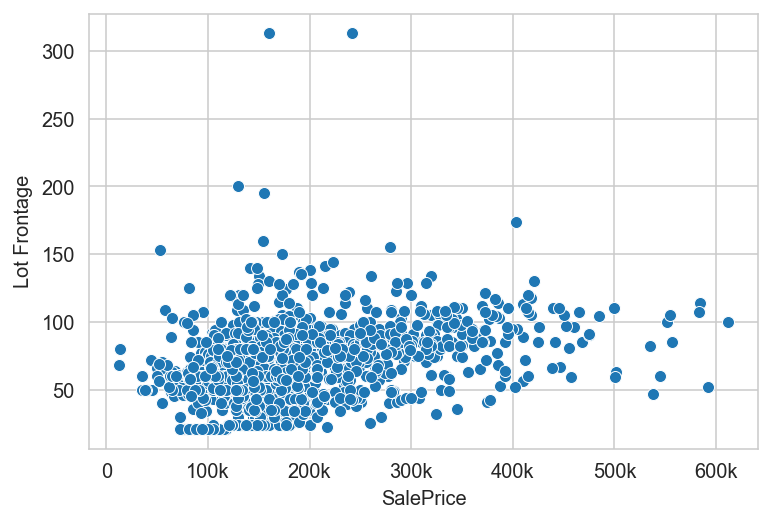

In [21]:
scatterplt(var='Lot Frontage')

_Outliers present:_

In [ ]:
train_df.loc[train_df['Lot Frontage']>300, ['Lot Frontage']]

#### Lot Area distribution:

In [ ]:
scatterplt(var='Lot Area')

_Outliers present:_

In [ ]:
train_df.loc[train_df['Lot Area']>100000, ['Lot Area']]

#### Year Built distribution:

In [ ]:
scatterplt(var='Year Built')

>_Appears to be an inverse exponential relationship between `Year Built` and `SalePrice`. Properties built before 2000 have a narrow range of `SalePrice`. While properties built after 2000 have a wide range of `SalePrice`._

_Outliers present:_

In [ ]:
train_df.loc[(train_df['Year Built']<1936) & (train_df['SalePrice']>290000)]

#### Year Remod/Add distribution:

In [ ]:
scatterplt(var='Year Remod/Add')

_No gross outliers._

#### Mas Vnr Area distribution:

In [ ]:
scatterplt(var='Mas Vnr Area')

_Outlier present:_

In [ ]:
train_df.loc[(train_df['Mas Vnr Area']>1400), ['Mas Vnr Area']]

#### BsmtFin SF 1 distribution:

In [ ]:
scatterplt(var='BsmtFin SF 1')

_Outliers present:_

In [ ]:
train_df.loc[(train_df['BsmtFin SF 1']>3500), ['BsmtFin SF 1']]

#### BsmtFin SF 2 distribution:

In [ ]:
scatterplt(var='BsmtFin SF 2')

_Outliers present:_

In [ ]:
train_df.loc[(train_df['BsmtFin SF 2']>1200), ['BsmtFin SF 2']]

>_Based on the 2 scatterplots above, the distributions of `BsmtFin SF 1` and `BsmtFin SF 2` have poor value in determining `SalePrice`. Also, these 2 features also have high multicollinearity based on VIF scores. So I will consider excluding these 2 features for optimisation of machine learning model if needed._ 

#### Bsmt Unf SF distribution:

In [ ]:
scatterplt(var='Bsmt Unf SF')

_No gross outliers._

#### Total Bsmt SF distribution:

In [ ]:
scatterplt(var='Total Bsmt SF')

_Outliers present:_

In [ ]:
train_df.loc[(train_df['Total Bsmt SF']>5000), ['Total Bsmt SF']]

#### 1st Flr SF distribution:

In [ ]:
scatterplt(var='1st Flr SF')

_Outliers present:_

In [ ]:
train_df.loc[(train_df['1st Flr SF']>4000), ['1st Flr SF']]

#### 2nd Flr SF distribution:

In [ ]:
scatterplt(var='2nd Flr SF')

_No gross outliers._

>_Based on the spread of data points for `2nd Flr SF` feature, with lots of '0's spread across the entire range of `SalePrice`, and the high VIF score signifying high multicollinearity, so I will consider excluding this feature for optimisation of machine learning model if needed since it will unlikely be useful to predict `SalePrice`._

#### Low Qual Fin SF:

In [ ]:
scatterplt(var='Low Qual Fin SF')

_Outliers present:_

In [ ]:
train_df.loc[(train_df['Low Qual Fin SF']>1000) | 
             ((train_df['Low Qual Fin SF']>500)&(train_df['SalePrice']>400000)), 
             ['Low Qual Fin SF','SalePrice']]

>_Based on the spread of data points for `Low Qual Fin SF` feature, with lots of '0's spread across the entire range of `SalePrice`, and the high VIF score signifying high multicollinearity, so I will consider excluding this feature for optimisation of machine learning model if needed since it will unlikely be useful to predict `SalePrice`._

#### Gr Liv Area distribution:

In [ ]:
scatterplt(var='Gr Liv Area')

_Outliers present:_

In [ ]:
train_df.loc[(train_df['Gr Liv Area']>4000), ['Gr Liv Area']]

#### Bsmt Full Bath distribution:

In [ ]:
scatterplt(var='Bsmt Full Bath')

>_Based on the spread of data points for `Bsmt Full Bath` feature, with lots of '0's spread across the entire range of `SalePrice`, and the high VIF score signifying high multicollinearity, so I will consider excluding this feature for optimisation of machine learning model if needed since it will unlikely be useful to predict `SalePrice`._

#### Bsmt Half Bath distribution:

In [ ]:
scatterplt(var='Bsmt Half Bath')

>_Based on the spread of data points for `Bsmt Half Bath` feature, with lots of '0's spread across the entire range of `SalePrice`, and the high VIF score signifying high multicollinearity, so I will consider excluding this feature for optimisation of machine learning model if needed since it will unlikely be useful to predict `SalePrice`._

#### Full Bath distribution:

In [ ]:
scatterplt(var='Full Bath')

_Outliers present:_

In [ ]:
train_df.loc[(train_df['Full Bath']==4), ['Full Bath','SalePrice']]

#### Half Bath distribution:

In [ ]:
scatterplt(var='Half Bath')

>_Based on the spread of data points for `Half Bath` feature, with lots of '0's spread across the entire range of `SalePrice`, and the high VIF score signifying high multicollinearity, so I will consider excluding this feature for optimisation of machine learning model if needed since it will unlikely be useful to predict `SalePrice`._

#### Bedroom AbvGr distribution:

In [ ]:
scatterplt(var='Bedroom AbvGr')

>_Based on the spread of data points for `Bedroom AbvGr` feature, with no discernable relationship with `SalePrice`, and the high VIF score signifying high multicollinearity, so I will consider excluding this feature for optimisation of machine learning model if needed since it will unlikely be useful to predict `SalePrice`._

#### Kitchen AbvGr distribution:

In [ ]:
scatterplt(var='Kitchen AbvGr')

>_Based on the spread of data points for `Kitchen AbvGr` feature, with no discernable relationship with `SalePrice`, and the high VIF score signifying high multicollinearity, so I will consider excluding this feature for optimisation of machine learning model if needed since it will unlikely be useful to predict `SalePrice`._

#### TotRms AbvGrd distribution: 

In [ ]:
scatterplt(var='TotRms AbvGrd')

_Outliers present:_

In [ ]:
train_df.loc[(train_df['TotRms AbvGrd']>12), ['TotRms AbvGrd']]

#### Fireplaces distribution:

In [ ]:
scatterplt(var='Fireplaces')

_No gross outliers. There is some sort of pattern between 0 to 2 `Fireplaces` and `SalePrice`._

#### Garage Cars distribution:

In [ ]:
scatterplt(var='Garage Cars')

_No gross outliers. There is some sort of trend between 0 to 3 `Garage Cars` and `SalePrice`._

#### Garage Area distribution:

In [ ]:
scatterplt(var='Garage Area')

_No gross outliers._

#### Wood Deck SF distribution:

In [ ]:
scatterplt(var='Wood Deck SF')

_Outlier present:_

In [ ]:
train_df.loc[(train_df['Wood Deck SF']>1400), ['Wood Deck SF']]

#### Open Porch SF distribution:

In [ ]:
scatterplt(var='Open Porch SF')

_No gross outliers._

#### Enclosed Porch distribution:

In [ ]:
scatterplt(var='Enclosed Porch')

_No gross outliers._

#### 3Ssn Porch distribution:

In [ ]:
scatterplt(var='3Ssn Porch')

>_Based on the spread of data points for `3Ssn Porch` feature, with a lot of '0's, and the high VIF score signifying high multicollinearity, so I will consider excluding this feature for optimisation of machine learning model if needed since it will unlikely be useful to predict `SalePrice`._

#### Screen Porch distribution:

In [ ]:
scatterplt(var='Screen Porch')

_No gross outliers._

#### Pool Area distribution:

In [ ]:
scatterplt(var='Pool Area')

>_Based on the spread of data points for `Pool Area` feature, with a lot of '0's, and the high VIF score signifying high multicollinearity, so I will consider excluding this feature for optimisation of machine learning model if needed since it will unlikely be useful to predict `SalePrice`._

#### Misc Val distribution:

In [ ]:
scatterplt(var='Misc Val')

>_Based on the spread of data points for `Misc Val` feature, with a lot of '0's, and the high VIF score signifying high multicollinearity, so I will consider excluding this feature for optimisation of machine learning model if needed since it will unlikely be useful to predict `SalePrice`._

#### Mo Sold distribution:

In [ ]:
scatterplt(var='Mo Sold')

_No gross outliers._

#### Yr Sold distribution:

In [ ]:
scatterplt(var='Yr Sold')

_No gross outliers._

#### SalePrice distribution:

In [ ]:
sns.histplot(data=train_df, x='SalePrice');

_Right skewed distribution for `SalePrice`. Most properties had a `SalePrice` between 100k and 250k. While the highest `SalePrice` is about 600k._

#### Decision List:

**Features to keep are:** <br>
[`Lot Frontage`](#Lot-Frontage-distribution:); [`Lot Area`](#Lot-Area-distribution:); [`Year Built`](#Year-Built-distribution:); [`Year Remod/Add`](#Year-Remod/Add-distribution:); [`Mas Vnr Area`](#Mas-Vnr-Area-distribution:); [`Bsmt Unf SF`](#Bsmt-Unf-SF-distribution:); [`Total Bsmt SF`](#Total-Bsmt-SF-distribution:); [`1st Flr SF`](#1st-Flr-SF-distribution:); [`Gr Liv Area`](#Gr-Liv-Area-distribution:); [`Full Bath`](#Full-Bath-distribution:); [`TotRms AbvGrd`](#TotRms-AbvGrd-distribution:); [`Fireplaces`](#Fireplaces-distribution:); [`Garage Cars`](#Garage-Cars-distribution:); [`Garage Area`](#Garage-Area-distribution:); [`Wood Deck SF`](#Wood-Deck-SF-distribution:); [`Open Porch SF`](#Open-Porch-SF-distribution:); [`Enclosed Porch`](#Enclosed-Porch-distribution:); [`Screen Porch`](#Screen-Porch-distribution:); [`Mo Sold`](#Mo-Sold-distribution:); [`Yr Sold`](#Yr-Sold-distribution:); 

**Features to consider for exclusion are:** <br>
[`BsmtFin SF 1`](#BsmtFin-SF-1-distribution:); [`BsmtFin SF 2`](#BsmtFin-SF-2-distribution:); [`2nd Flr SF`](#2nd-Flr-SF-distribution:); [`Low Qual Fin SF`](#Low-Qual-Fin-SF-distribution:); [`Bsmt Full Bath`](#Bsmt-Full-Bath-distribution:); [`Bsmt Half Bath`](#Bsmt-Half-Bath-distribution:); [`Half Bath`](#Half-Bath-distribution:); [`Bedroom AbvGr`](#Bedroom-AbvGr-distribution:); [`Kitchen AbvGr`](#Kitchen-AbvGr-distribution:); [`3Ssn Porch`](#3Ssn-Porch-distribution:); [`Pool Area`](#Pool-Area-distribution:); [`Misc Val`](#Misc-Val-distribution:); 

_`Garage Yr Blt` will not be explored since it is excluded in `train_drop`._

**Target feature:**[`SalePrice`](#SalePrice-distribution:)

## Dealing with outliers:
---

In [23]:
outlier_list = [960,1335,471,694,1035,1141,1897,1939,1409,1885,770,1692,828,966]

In [24]:
print(drop_set.intersection(set(outlier_list)))

set()


_Looks like the outliers were not dropped in `train_drop` after comparing the outlier indices with those in the `drop_set`. I will drop the outliers before train-test-split so that test set is accurate representation of train set._ 

#### train_df1

In [25]:
train_df1 = train_drop.drop(index=outlier_list)

## Train-test-split:
---

In [26]:
# import modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [27]:
# Create X and y
'''
I would also drop `Id` and `PID` features
since they seem to be just serial numbers, 
and are not meaningful in real world setting for predicting sales price
'''
X = train_df1.drop(columns=['SalePrice','Id','PID'])
y = train_df1['SalePrice']

In [28]:
# create train-test-split sets
# since this is not a classification problem, y cannot be stratified
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# check X_train for null values, since `Lot Frontage` is not yet imputed
X_train.isnull().sum().sort_values(ascending=False)[:3]

## Processed Dataframes: 
---

* [Train Data](#train_df)
* [Dummified Train Data](#train_dum)
* [Dropped rows Train Data](#train_drop)
* [No outliers Train Data](#train_df1)
* [Imputed `Lot Frontage` train-set data](#imp_X_train)

## Imputation of train set:
---

_KNN imputation will impute all missing values in a dataframe. To ensure that only the feature i.e. `Lot Frontage` is imputed, only that feature can have missing values, all other features must be complete. I wish to keep imputation at the minimum as sometimes imputed data can exaggerate any bias already present._<br><br>
_`Lot Frontage` has a sizable portion of missing values that makes dropping rows sacrificing sizable amount of limited data, but yet not sizable enough (< 50%) that would make imputation impossible or likely inaccurate._<br><br> 
_`KNN imputation` on missing values in `Lot Frontage` feature is as follows:_

### imp_X_train

In [29]:
# import imputer from sklearn module
from sklearn.impute import KNNImputer

In [30]:
# instantiate imputer
imp = KNNImputer()

In [31]:
'''
fit and transform X_train
create new dataframe variable with the imputed `Lot Frontage` values
'''
imp_X_train = imp.fit_transform(X_train)

'''
had to impute my X_test too, otherwise I could not get prediction score for X_test set
'''
imp_X_test = imp.transform(X_test)

In [32]:
imp_X_train = pd.DataFrame(imp_X_train, columns=X_train.columns)
imp_X_test = pd.DataFrame(imp_X_test, columns=X_test.columns)

In [ ]:
# no null values left after imputation
print(' imp_X_train '.center(18, "="))
print(imp_X_train.isnull().sum().sort_values(ascending=False)[:3])
print()
print(' imp_X_test '.center(18, '='))
print(imp_X_test.isnull().sum().sort_values(ascending=False)[:3])

## LassoCV
---

_**Using LassoCV to narrow down important features, and check if performance is ok**_

In [33]:
from sklearn.linear_model import LassoCV

In [ ]:
# check range of values in features, check if standardisation is important
imp_X_train.describe().T

_I realised the VIF = np.nan values correspond to features that have zero min and max values. Which means these features will not be useful in predicting `SalePrice` since there is no variation in values._

In [34]:
'''
Function to find features from the .describe() table that have mean == 0, 
and put in a list.
'''
def zero_mean(df):
    drop_list = []
    for x, y in zip(df['mean'], df.index):
        if x == 0.0:
            drop_list.append(y)
    return drop_list

In [35]:
describe_df = imp_X_train.describe().T

In [36]:
col_list = zero_mean(describe_df)

imp_X_train.drop(columns=col_list, inplace=True)
imp_X_test.drop(columns=col_list, inplace=True) # align features between train and test set

In [37]:
imp_X_train.shape # left 239 features

(1408, 239)

_**Construct LASSO instantiate function**_

In [38]:
'''
train = imp_X_train
test = imp_X_test
'''
def lasso_cv(train, test):
    ss = StandardScaler()  # standardise X_train, X_test
    Z_train = ss.fit_transform(train)
    Z_test = ss.transform(test) 
    
    ######## Lasso cv model ########
    l_alphas = np.logspace(-3, 0, 100) # list of alphas to check
    lasso_cv = LassoCV(alphas=l_alphas, cv=5, max_iter=50000) # cross validate 5 folds
    lasso_cv.fit(Z_train, y_train)
    
    ########
    return lasso_cv

In [39]:
# lasso cv best alpha value
lasso_cv(imp_X_train, imp_X_test).alpha_

1.0

_**Evaluate LassoCV model**_

In [40]:
from sklearn.metrics import mean_squared_error

_**Construct function for LASSO model evaluation metrics**_

In [41]:
def lasso_metrics(model, train, test): 
    y_train_pred = model.predict(train)
    y_test_pred = model.predict(test)

    y_bar = np.repeat(np.mean(y_train),(len(y_train)))
    y_bar_rmse = mean_squared_error(y_train, y_bar, squared=False)

    rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
    rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)

    perc_diff = (rmse_train - rmse_test)/rmse_train * 100

    print(f'y_bar rmse: {y_bar_rmse}')
    print(f'Train rmse: {rmse_train}')
    print(f'Test rmse: {rmse_test}')
    print(f'perc_diff: {perc_diff} %')

In [42]:
model = lasso_cv(imp_X_train, imp_X_test)

lasso_metrics(model, imp_X_train, imp_X_test)

y_bar rmse: 77440.56492336537
Train rmse: 130384756.23858207
Test rmse: 134043180.44155975
perc_diff: -2.8058680389626023 %


C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(
C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(


>_**My model is performing worse than baseline. My current lasso model is useless.**_

In [43]:
# get the names of the features that lasso zeroed-out
lasso_model = lasso_cv(imp_X_train, imp_X_test)

np.array(imp_X_train.columns)[abs(lasso_model.coef_) == 0]

array(['Utilities', 'misc_f_Shed', 'alley_Grvl', 'fence_GdPrv',
       'grge_t_Detchd', 'bsmtf_t2_Unf', 'mvt_None', 'msz_RL', 'lt_s_Reg',
       'ld_c_Lvl', 'lt_c_Inside', 'nbrhd_ClearCr', 'cdn_1_Feedr',
       'cdn_2_Feedr', 'bdg_t_Duplex', 'hse_s_1.5Fin', 'rf_s_Gable',
       'rf_m_CompShg', 'ex_1_AsbShng', 'ex_1_HdBoard', 'fdn_PConc',
       'elec_FuseF', 'pvdr_N'], dtype=object)

_**Drop features that LASSO zero-ed out**_

In [44]:
col_list = np.array(imp_X_train.columns)[abs(lasso_model.coef_) == 0]

imp_X_train.drop(columns=col_list, inplace=True)
imp_X_test.drop(columns=col_list, inplace=True)

_**Rerun LASSO**_

In [45]:
# lasso cv best alpha value
lasso_cv(imp_X_train, imp_X_test).alpha_

1.0

_**Evaluate lasso model 2nd time**_

In [46]:
model = lasso_cv(imp_X_train, imp_X_test)

lasso_metrics(model, imp_X_train, imp_X_test)

y_bar rmse: 77440.56492336537
Train rmse: 130472950.20527524
Test rmse: 134133423.77467807
perc_diff: -2.8055421170777124 %


C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(
C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(


In [47]:
# get the names of the features that lasso zeroed-out
lasso_model = lasso_cv(imp_X_train, imp_X_test)

np.array(imp_X_train.columns)[abs(lasso_model.coef_) == 0]

array(['bsmtf_t1_BLQ'], dtype=object)

_**Drop feature that LASSO zero-ed out**_

In [48]:
col_list = np.array(imp_X_train.columns)[abs(lasso_model.coef_) == 0]

imp_X_train.drop(columns=col_list, inplace=True)
imp_X_test.drop(columns=col_list, inplace=True)

_**Rerun LASSO**_

In [49]:
# lasso cv best alpha value
lasso_cv(imp_X_train, imp_X_test).alpha_

1.0

_**Evaluate lasso model 3rd time**_

In [50]:
model = lasso_cv(imp_X_train, imp_X_test)

lasso_metrics(model, imp_X_train, imp_X_test)

y_bar rmse: 77440.56492336537
Train rmse: 129656325.70971258
Test rmse: 133297834.16921681
perc_diff: -2.8085852653708554 %


C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(
C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(


In [51]:
# lasso model not zero-ing anymore features
lasso_model = lasso_cv(imp_X_train, imp_X_test)

np.array(imp_X_train.columns)[abs(lasso_model.coef_) == 0]

array([], dtype=object)

In [52]:
imp_X_train.shape # left with 215 features

(1408, 215)

##  Checking for multicollinearity:
---

>_Because VIF uses multi-linear regression on independent variables to test for multicolinearity, the categorical features have to be dummified. Also, it cannot handle features with missing values._<br><br> 
_Now that the data is dummified, cleaned from missing values, and imputed for `Lot Frontage` feature, I wish to check if there is multicollinearity between features. If so, may consider dropping some of the features._<br><br> 
_In this situation with so many features to compare, I will use `Variance Inflation Factors`(VIF) [(statisticsbyjim](https://statisticsbyjim.com/regression/multicollinearity-in-regression-analysis/) and [statisticsbyjim)](https://statisticsbyjim.com/regression/variance-inflation-factors/)._<br><br> 
_From `statsmodels.stats.outliers_influence` library, import `variance_inflation_factor` [(geeksforgeeks)](https://www.geeksforgeeks.org/detecting-multicollinearity-with-vif-python/)_

In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

_I was getting warnings using VIF, so I found this [advice](https://stackoverflow.com/questions/42658379/variance-inflation-factor-in-python). But adding a constant did not help. <br><br>
I also tried centering my features [(code below converted to Raw NBConvert to reduce run errors)](#This-is-the-code-I-tried-with-centering-of-features:), but that also did not help with adjusting the VIF values or resolving warnings.<br><br>
So I decided to just stick with the code using `imp_X_train` (with constant since creator of statsmodel VIF recommends having one but no centering of features) to calculate the VIF._

In [54]:
'''
to show all columns for null values assessment. 
Default only showed top 5 and bottom 5 columns
''' 
pd.options.display.min_rows = 200

In [55]:
def vif_scores(df):
    X = df.assign(const=1) # add a constant
    
    vif_data = pd.DataFrame()  # initiate VIF dataframe
    vif_data["feature"] = X.columns
    
    vif_data["vif"] = sorted([  # sort to show values with highest VIF scores
        variance_inflation_factor(X.values, i) # calculate VIF for each feature
        for i in range(len(X.columns))], reverse=True) 
    
    return vif_data

In [56]:
vif_df = vif_scores(imp_X_train)

C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)
C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\regression\linear_model.py:1736: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 - self.ssr/self.centered_tss


_**Function to construct list of features to drop using VIF scores**_

In [57]:
def vif_above_10(df):
    drop_list = []
    for x, y in zip(df['vif'], df['feature']): 
        if x > 10:
            drop_list.append(y)
    
    for x in drop_list:
        if x == 'const':
            drop_list.remove(x)
    return drop_list

In [ ]:
len(vif_above_10(vif_df))

_**Drop features that have VIF score >10**_

In [58]:
col_list = vif_above_10(vif_df)

imp_X_train.drop(columns=col_list, inplace=True)
imp_X_test.drop(columns=col_list, inplace=True)

_**rerun VIF**_

In [59]:
vif_df = vif_scores(imp_X_train)

C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)
C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\regression\linear_model.py:1736: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 - self.ssr/self.centered_tss


In [60]:
print(vif_df)

            feature       vif
0     grge_t_2Types       inf
1     grge_t_Attchd       inf
2    grge_t_Basment       inf
3    grge_t_BuiltIn       inf
4    grge_t_CarPort       inf
5        grge_t_nan       inf
6      bsmtf_t2_ALQ       inf
7      bsmtf_t2_BLQ       inf
8      bsmtf_t2_GLQ       inf
9      bsmtf_t2_LwQ       inf
10     bsmtf_t2_Rec       inf
11     bsmtf_t2_nan       inf
12     bsmtf_t1_ALQ       inf
13     bsmtf_t1_GLQ       inf
14     bsmtf_t1_LwQ       inf
15     bsmtf_t1_Rec       inf
16     bsmtf_t1_Unf       inf
17     bsmtf_t1_nan       inf
18       mvt_BrkCmn       inf
19      mvt_BrkFace       inf
20        mvt_Stone       inf
21      msz_A (agr)       inf
22      msz_C (all)       inf
23           msz_FV       inf
24           msz_RH       inf
25           msz_RM       inf
26          st_Grvl       inf
27          st_Pave       inf
28         lt_s_IR1       inf
29         lt_s_IR2       inf
..              ...       ...
122     ex_2_Stucco  1.323445
123    ex_

_**Drop features 2nd time that have VIF score >10**_

In [61]:
col_list = vif_above_10(vif_df)

imp_X_train.drop(columns=col_list, inplace=True)
imp_X_test.drop(columns=col_list, inplace=True)

_**rerun VIF**_

In [62]:
vif_df = vif_scores(imp_X_train)

C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)
C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\regression\linear_model.py:1736: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 - self.ssr/self.centered_tss


In [ ]:
print(vif_df)

_**Drop features 3rd time that have VIF score >10**_

In [63]:
col_list = vif_above_10(vif_df)

imp_X_train.drop(columns=col_list, inplace=True)
imp_X_test.drop(columns=col_list, inplace=True)

_**rerun VIF**_

In [64]:
vif_df = vif_scores(imp_X_train)

C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)
C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\regression\linear_model.py:1736: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 - self.ssr/self.centered_tss


In [ ]:
print(vif_df)

_**Drop features 4th time that have VIF score >10**_

In [65]:
col_list = vif_above_10(vif_df)

imp_X_train.drop(columns=col_list, inplace=True)
imp_X_test.drop(columns=col_list, inplace=True)

_**rerun VIF**_

In [66]:
vif_df = vif_scores(imp_X_train)

C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)
C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\regression\linear_model.py:1736: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 - self.ssr/self.centered_tss


In [ ]:
print(vif_df)

_**Drop features 5th time that have VIF score >10**_

In [67]:
col_list = vif_above_10(vif_df)

imp_X_train.drop(columns=col_list, inplace=True)
imp_X_test.drop(columns=col_list, inplace=True)

_**rerun VIF**_

In [68]:
vif_df = vif_scores(imp_X_train)

C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)
C:\Users\Maybelle\anaconda3\lib\site-packages\statsmodels\regression\linear_model.py:1736: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 - self.ssr/self.centered_tss


In [61]:
print(vif_df)

        feature       vif
0      htg_GasW       inf
1      htg_Grav       inf
2      htg_OthW       inf
3      htg_Wall       inf
4    elec_FuseA       inf
5    elec_FuseP       inf
6      elec_Mix       inf
7    elec_SBrkr       inf
8        pvdr_P       inf
9        pvdr_Y  5.348248
10    sle_t_COD  4.875160
11    sle_t_CWD  1.309940
12    sle_t_Con  1.206606
13  sle_t_ConLD  1.176309
14  sle_t_ConLI  1.053007
15  sle_t_ConLw  1.048392
16    sle_t_New  1.046917
17    sle_t_Oth  1.027996
18    sle_t_WD   1.000251
19        const  0.000000


## Rerun Lasso Model
---

In [69]:
# lasso cv best alpha value
lasso_cv(imp_X_train, imp_X_test).alpha_

1.0

_**Evaluate lasso model**_

In [70]:
model = lasso_cv(imp_X_train, imp_X_test)

lasso_metrics(model, imp_X_train, imp_X_test)

y_bar rmse: 77440.56492336537
Train rmse: 78437.65938906398
Test rmse: 78776.66115293476
perc_diff: -0.43219260558155337 %


C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(
C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(


>_Huge improvement in `rmse` for my model, but still worse than baseline, so my model is still useless, but less useless._

In [71]:
# feature that lasso model zero-ed out
lasso_model = lasso_cv(imp_X_train, imp_X_test)

np.array(imp_X_train.columns)[abs(lasso_model.coef_) == 0]

array(['sle_t_WD '], dtype=object)

In [72]:
# drop feature that Lasso zero-ed out
col_list = np.array(imp_X_train.columns)[abs(lasso_model.coef_) == 0]

imp_X_train.drop(columns=col_list, inplace=True)
imp_X_test.drop(columns=col_list, inplace=True)

_**Rerun lasso model 2nd time**_

In [73]:
# lasso cv best alpha value
lasso_cv(imp_X_train, imp_X_test).alpha_

1.0

_**Evaluate lasso model**_

In [74]:
model = lasso_cv(imp_X_train, imp_X_test)

lasso_metrics(model, imp_X_train, imp_X_test)

y_bar rmse: 77440.56492336537
Train rmse: 78436.03570468177
Test rmse: 78775.38121009886
perc_diff: -0.43263979670614156 %


C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(
C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(


In [75]:
# lasso model not zero-ing out anymore features
lasso_model = lasso_cv(imp_X_train, imp_X_test)

np.array(imp_X_train.columns)[abs(lasso_model.coef_) == 0]

array([], dtype=object)

In [76]:
imp_X_train.shape # 18 features left 

(1408, 18)

## Repeat multicollinearity check
---

In [77]:
vif_df = vif_scores(imp_X_train) # re-run the VIF calculation function

In [78]:
print(vif_df)

        feature        vif
0      htg_GasW  67.106349
1      htg_Grav   5.348248
2      htg_OthW   4.875160
3      htg_Wall   1.309940
4    elec_FuseA   1.206606
5    elec_FuseP   1.176309
6      elec_Mix   1.053007
7    elec_SBrkr   1.048392
8        pvdr_P   1.046917
9        pvdr_Y   1.027996
10    sle_t_COD   1.017955
11    sle_t_CWD   1.008952
12    sle_t_Con   1.008547
13  sle_t_ConLD   1.007820
14  sle_t_ConLI   1.004525
15  sle_t_ConLw   1.002320
16    sle_t_New   1.001484
17    sle_t_Oth   1.000748
18        const   1.000251


In [79]:
col_list = vif_above_10(vif_df) # drop features that have VIF score above 10

imp_X_train.drop(columns=col_list, inplace=True)
imp_X_test.drop(columns=col_list, inplace=True)

_**Rerun lasso again**_

In [80]:
# lasso cv best alpha value
lasso_cv(imp_X_train, imp_X_test).alpha_

1.0

In [81]:
model = lasso_cv(imp_X_train, imp_X_test)

lasso_metrics(model, imp_X_train, imp_X_test)

y_bar rmse: 77440.56492336537
Train rmse: 78442.18433914514
Test rmse: 78771.71210755434
perc_diff: -0.4200899951797428 %


C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(
C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(


In [82]:
# lasso model not zero-ing out anymore features
lasso_model = lasso_cv(imp_X_train, imp_X_test)

np.array(imp_X_train.columns)[abs(lasso_model.coef_) == 0]

array([], dtype=object)

>_This is the best performing Lasso CV model I can get so far, dropping any features further has resulted in worsening of `rmse` scores for both train and test set scores. Unfortunately, it is still worse than baseline `rmse`._

## GridSearch CV
---

[GridSearch + Pipeline multiple models reference](https://ryan-reilly.medium.com/gridsearch-pipelines-of-multiple-models-on-multiclass-classification-e9124b6ea2e3)

_**Isolate columns desired in X_train**_

In [83]:
print(imp_X_train.columns.tolist())
len(imp_X_train.columns.tolist())

['htg_Grav', 'htg_OthW', 'htg_Wall', 'elec_FuseA', 'elec_FuseP', 'elec_Mix', 'elec_SBrkr', 'pvdr_P', 'pvdr_Y', 'sle_t_COD', 'sle_t_CWD', 'sle_t_Con', 'sle_t_ConLD', 'sle_t_ConLI', 'sle_t_ConLw', 'sle_t_New', 'sle_t_Oth']


17

In [84]:
X_train_17 = X_train[imp_X_train.columns.tolist()]
X_test_17 = X_test[imp_X_train.columns.tolist()]

_**Instantiate Pipeline for GridSearchCV, built-in standardisation**_

In [85]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

In [86]:
# Instantiate a StandardScaler + LR pipeline.
pipe1 = Pipeline([
    ('ss', StandardScaler()),
    ('lr', LinearRegression())
])

# Instantiate a StandardScaler + Ridge pipeline.
pipe2 = Pipeline([
    ('ss', StandardScaler()),
    ('ridge', Ridge())
])

# Instantiate a StandardScaler + LASSO pipeline.
pipe3 = Pipeline([
    ('ss', StandardScaler()),
    ('lasso', Lasso())
])

# Instantiate a StandardScaler + ElasticNet pipeline.
pipe4 = Pipeline([
    ('ss', StandardScaler()),
    ('enet', ElasticNet())
])

In [87]:
# Create dictionary of hyperparameters.
enet_ratio = [.5,.8,.9,.95]
n_neighbors = [3,5,10]
alpha_l = [1.,10.,100.,500.,1000.]

pipe1_params = {'lr__fit_intercept': [True, False],
                'lr__positive': [True, False]
               }

pipe2_params = {'ridge__alpha': alpha_l
               }

pipe3_params = {'lasso__alpha': alpha_l,
                'lasso__max_iter': [10000, 50000]
               }

pipe4_params = {'enet__alpha': alpha_l,
                'enet__l1_ratio': enet_ratio
               }

_**Instantiate GridSearchCV**_

In [88]:
from sklearn.model_selection import GridSearchCV

In [89]:
cv_ct = 5
score = 'neg_root_mean_squared_error'

pipe1_gs = GridSearchCV(pipe1,
                       pipe1_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

pipe2_gs = GridSearchCV(pipe2,
                       pipe2_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

pipe3_gs = GridSearchCV(pipe3,
                       pipe3_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

pipe4_gs = GridSearchCV(pipe4,
                       pipe4_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

_**Fit models from GridSearchCV pipeline**_

In [90]:
# combine the grids to loop through
grids = [pipe1_gs, pipe2_gs, pipe3_gs, pipe4_gs]

for pipe in grids:
    pipe.fit(X_train_17,y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


_**Evaluate models**_

In [91]:
y_bar = np.repeat(np.mean(y_train),(len(y_train)))
y_bar_rmse = mean_squared_error(y_train, y_bar, squared=False)

grid_dict = {0: 'Linear regression', 1: 'Ridge regression',
            2: 'Lasso regression', 3: 'ElasticNet regression'}

for i, model in enumerate(grids):
    print(f'y_bar rmse: {y_bar_rmse}')
    print(f'{grid_dict[i]} train rmse: {model.score(X_train_17, y_train)}')
    print(f'{grid_dict[i]} test rmse: {model.score(X_test_17, y_test)}')
    print(f'{grid_dict[i]} %_diff rmse: {(model.score(X_train_17, y_train)-model.score(X_test_17, y_test))/model.score(X_train_17, y_train)}')
    print(f'{grid_dict[i]} Best Params: {model.best_params_}')
    print()

y_bar rmse: 77440.56492336537
Linear regression train rmse: -67186.37046968259
Linear regression test rmse: -70250.6792104102
Linear regression %_diff rmse: -0.0456090829033601
Linear regression Best Params: {'lr__fit_intercept': True, 'lr__positive': False}

y_bar rmse: 77440.56492336537
Ridge regression train rmse: -67226.42447643484
Ridge regression test rmse: -70283.02266477297
Ridge regression %_diff rmse: -0.04546721340816771
Ridge regression Best Params: {'ridge__alpha': 100.0}

y_bar rmse: 77440.56492336537
Lasso regression train rmse: -67274.49539164921
Lasso regression test rmse: -70236.85186731738
Lasso regression %_diff rmse: -0.04403387135678005
Lasso regression Best Params: {'lasso__alpha': 1000.0, 'lasso__max_iter': 10000}

y_bar rmse: 77440.56492336537
ElasticNet regression train rmse: -67207.90537144506
ElasticNet regression test rmse: -70269.5793073595
ElasticNet regression %_diff rmse: -0.045555264949757965
ElasticNet regression Best Params: {'enet__alpha': 1.0, 'ene

>_Surprisingly, by GridSearchCV, all my models are performing better than baseline. Still bad absolute `RMSE` scores, but better than baseline. Since the `% diff` values don't differ much between the various linear models, I will choose the model with the **best test rmse** for making predictions on the [test.csv](./datasets/test.csv). That would be the **LASSO model**._

## Kaggle Submission preparation
---

**Contents:**
* [Original test set](#test_df)
* [Dummified test set](#test_dum)
* [Features isolated test set](#test_drop)
* [Make predictions](#Make-predictions-using-Lasso-Model-from-GridSearchCV)

### test_df

_Import [test.csv](./datasets/test.csv)_

In [103]:
# use test.csv to generate predictions for submission
test_df = pd.read_csv('./datasets/test.csv')

In [104]:
test_df.head(3)

,Id,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type
0,2658,902301120,190,RM,69.0,9142,Pave,Grvl,Reg,Lvl,...,0,0,0,NaN,NaN,NaN,0,4,2006,WD
1,2718,905108090,90,RL,NaN,9662,Pave,NaN,IR1,Lvl,...,0,0,0,NaN,NaN,NaN,0,8,2006,WD
2,2414,528218130,60,RL,58.0,17104,Pave,NaN,IR1,Lvl,...,0,0,0,NaN,NaN,NaN,0,9,2006,New


_Dummify test_df and resolve any null values before getting prediction values because of model restrictions_

### test_dum

In [102]:
'''
Final features to isolate in test set so that model can accept test data to make predictions
'''
print(X_train_17.columns.tolist())
len(X_train_17.columns.tolist())

['htg_Grav', 'htg_OthW', 'htg_Wall', 'elec_FuseA', 'elec_FuseP', 'elec_Mix', 'elec_SBrkr', 'pvdr_P', 'pvdr_Y', 'sle_t_COD', 'sle_t_CWD', 'sle_t_Con', 'sle_t_ConLD', 'sle_t_ConLI', 'sle_t_ConLw', 'sle_t_New', 'sle_t_Oth']


17

_Since the final features that were fitted into the model were all dummy variables, not any of the orginal features, or the categorical features that were ordinal-labelled, I decided to just dummify all categorical features in the test set for code simplicity and then extract the features that were used to fit the model._

In [105]:
prefix_dict = {'Pool QC': 'pool_qc', 'Misc Feature': 'misc_f', 'Alley': 'alley', 'Fence': 'fence',
              'Fireplace Qu': 'fire_qu', 'Garage Finish': 'grge_f', 'Garage Qual': 'grge_q',
              'Garage Cond': 'grge_c', 'Garage Type': 'grge_t', 'Bsmt Exposure': 'bsmt_e', 
              'BsmtFin Type 2': 'bsmtf_t2', 'BsmtFin Type 1': 'bsmtf_t1', 'Bsmt Cond': 'bsmt_c',
              'Bsmt Qual': 'bsmt_q', 'Mas Vnr Type': 'mvt',
              'MS Zoning': 'msz', 'Street': 'stt', 'Lot Shape': 'lot_s', 'Land Contour': 'ld_c',
              'Utilities': 'Utls', 'Lot Config': 'lt_c', 'Land Slope': 'ld_s', 
               'Neighborhood': 'nbrhd', 'Condition 1': 'cdn_1', 'Condition 2': 'cdn_2',
              'Bldg Type': 'bdg_t', 'House Style': 'hse_s', 'Roof Style': 'rf_s', 
               'Roof Matl': 'rf_m', 'Exterior 1st': 'ex_1', 'Exterior 2nd': 'ex_2', 
               'Exter Qual': 'ex_q', 'Exter Cond': 'ex_c', 'Foundation': 'fdn', 'Heating': 'htg',
               'Heating QC': 'htg_qc', 'Central Air': 'cair', 'Electrical': 'elec', 
               'Kitchen Qual': 'kc_q', 'Functional': 'func', 'Paved Drive': 'pvdr', 
               'Sale Type': 'sle_t'
              }

columns_list = ['Pool QC','Misc Feature','Alley','Fence','Fireplace Qu','Garage Finish',
               'Garage Qual','Garage Cond','Garage Type','Bsmt Exposure','BsmtFin Type 2',
               'BsmtFin Type 1','Bsmt Cond','Bsmt Qual','Mas Vnr Type',
               'MS Zoning','Street','Lot Shape','Land Contour','Utilities','Lot Config',
               'Land Slope','Neighborhood','Condition 1','Condition 2','Bldg Type', 'House Style',
               'Roof Style','Roof Matl','Exterior 1st','Exterior 2nd','Exter Qual','Exter Cond',
               'Foundation','Heating','Heating QC','Central Air','Electrical','Kitchen Qual',
               'Functional','Paved Drive','Sale Type']

test_dum = pd.get_dummies(data=test_df, prefix=prefix_dict, dummy_na=True, columns=columns_list)
test_dum.head(3)

,Id,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,sle_t_CWD,sle_t_Con,sle_t_ConLD,sle_t_ConLI,sle_t_ConLw,sle_t_New,sle_t_Oth,sle_t_VWD,sle_t_WD,sle_t_nan
0,2658,902301120,190,69.0,9142,6,8,1910,1950,0.0,...,0,0,0,0,0,0,0,0,1,0
1,2718,905108090,90,NaN,9662,5,4,1977,1977,0.0,...,0,0,0,0,0,0,0,0,1,0
2,2414,528218130,60,58.0,17104,7,5,2006,2006,0.0,...,0,0,0,0,0,1,0,0,0,0


In [106]:
# relook at what null values that are left undummified
test_dum.isnull().sum().sort_values(ascending=False)[:4]

Lot Frontage     160
Garage Yr Blt     45
Mas Vnr Area       1
Id                 0
dtype: int64

### test_drop

_Since I will not be adjusting my current model, I will have to impute 3 new features in the test set based on imputation fitted on train data set. <br> [Reference](https://stackoverflow.com/questions/44631909/different-number-of-features-in-train-and-test-sets-random-forest-sklearn-pyth)_

In [109]:
# construct new dummy features in test set to match features used in fitted model
test_dum['htg_OthW'], test_dum['htg_Wall'], test_dum['elec_Mix'] = [0, 0, 0]

In [110]:
# check if features are constructed correctly
test_dum[['htg_OthW', 'htg_Wall', 'elec_Mix']].head(3)

,htg_OthW,htg_Wall,elec_Mix
0,0,0,0
1,0,0,0
2,0,0,0


In [111]:
'''
created new dataframe variable just in case I needed 
the dataframe without any dropped rows and/or feature(s) to go back to
'''
test_drop = test_dum[X_train_17.columns.tolist()]

In [113]:
# check for missing values
test_drop.isnull().sum().sort_values(ascending=False)[:3]

htg_Grav     0
sle_t_COD    0
sle_t_New    0
dtype: int64

### Make predictions using Lasso Model from GridSearchCV

In [117]:
# generate predictions using the GridsearchCV Lasso model fitted on the training set
test_pred = pipe3_gs.predict(test_drop)
len(test_pred)

878

In [118]:
len(test_df)

878

In [120]:
# isolate `Id` column from test_df
test_final = test_df[['Id']]
test_final.head(3)

,Id
0,2658
1,2718
2,2414


In [123]:
'''
predictions are in a list format. 
Need to convert to dataframe and join with `Id` column
'''
test_final['SalePrice'] = test_pred
test_final.head(3)

C:\Users\Maybelle\AppData\Local\Temp\ipykernel_14844\1685190965.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_final['SalePrice'] = test_pred


,Id,SalePrice
0,2658,139889.917116
1,2718,182406.652692
2,2414,277293.465739


In [124]:
# Export file for submission
test_final.to_csv('./kaggle_submission.csv', index=False)

>User: yxmauw <br>
Kaggle score achieved: 75592.17129 <br>
Private score: 67678.08413

## Evaluation of model features effect on `SalePrice`
---

In [92]:
# generate predictions using the GridsearchCV Lasso model fitted on the training set
train_pred = pipe3_gs.predict(X_train_17)
len(train_pred)

1408

In [93]:
X_train_17.head(3)

,htg_Grav,htg_OthW,htg_Wall,elec_FuseA,elec_FuseP,elec_Mix,elec_SBrkr,pvdr_P,pvdr_Y,sle_t_COD,sle_t_CWD,sle_t_Con,sle_t_ConLD,sle_t_ConLI,sle_t_ConLw,sle_t_New,sle_t_Oth
566,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0
1084,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0
1909,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0


In [100]:
# join X_train_17, true SalePrice and predicted SalePrice
pred_df = pd.concat([X_train_17, y_train], axis=1)
pred_df['SalePrice_pred'] = train_pred

,htg_Grav,htg_OthW,htg_Wall,elec_FuseA,elec_FuseP,elec_Mix,elec_SBrkr,pvdr_P,pvdr_Y,sle_t_COD,sle_t_CWD,sle_t_Con,sle_t_ConLD,sle_t_ConLI,sle_t_ConLw,sle_t_New,sle_t_Oth,SalePrice,SalePrice_pred
566,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,164500,182406.652692
1084,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,383000,182406.652692
1909,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,333168,182406.652692


In [101]:
pred_df.head(20)

,htg_Grav,htg_OthW,htg_Wall,elec_FuseA,elec_FuseP,elec_Mix,elec_SBrkr,pvdr_P,pvdr_Y,sle_t_COD,sle_t_CWD,sle_t_Con,sle_t_ConLD,sle_t_ConLI,sle_t_ConLw,sle_t_New,sle_t_Oth,SalePrice,SalePrice_pred
566,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,164500,182406.652692
1084,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,383000,182406.652692
1909,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,333168,182406.652692
1381,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,120000,182406.652692
1334,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,281213,182406.652692
853,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,157000,182406.652692
983,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,156932,277293.465739
291,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,108000,139889.917116
1643,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,61500,124940.729831
753,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,213500,182406.652692
